# Analysis: Clustering, PCA, Validation, Profiling, Association Mining

**UGDSAI 29 · Group 4 · Aaryan, Daksh, Mayank**

**Input:** `data/videos_features.csv` (one row per video, 25+ engineered features)
**Output:** plots, cluster assignments, association rules, the 4 hero visuals for the deck.

## Structure
1. Load and preprocess (impute, scale, encode)
2. PCA — explained variance and dominant axes
3. Clustering — K-Means scan, choose `k` carefully
4. Compare K-Means vs Agglomerative vs DBSCAN
5. Validate with silhouette + ARI
6. Profile the clusters and name them as viral archetypes
7. Hero visuals: 2D map, lifecycle curves, fingerprint heatmap
8. Association mining on tag baskets

In [1]:
import sys; sys.path.insert(0, '../scripts')
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

from features import build_features
from analysis import (
    preprocess, run_pca, kmeans_scan, suggest_k,
    fit_kmeans, fit_dbscan, fit_agglomerative,
    k_distance_curve, profile_clusters, cluster_sizes,
    build_tag_baskets, mine_rules, umap_embed,
)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# === SWITCH HERE WHEN REAL DATA IS READY ===
INPUT_CSV = '../data/master_snapshots_synthetic.csv'   # synthetic for dev
# INPUT_CSV = '../data/master_snapshots.csv'           # real data

FIG_DIR = Path('../docs/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load and engineer features

In [2]:
snapshots = pd.read_csv(INPUT_CSV)
print(f'Snapshots: {len(snapshots):,} rows, {snapshots["video_id"].nunique():,} unique videos')

features = build_features(snapshots, min_obs=2)
print(f'Feature matrix: {features.shape[0]} videos x {features.shape[1]} features')
features.to_csv('../data/videos_features.csv')
features.head(3)

Snapshots: 976 rows, 340 unique videos


Feature matrix: 266 videos x 27 features


,peak_views_per_hour,mean_views_per_hour,hours_to_first_trend,decay_log_slope_48h,half_life_hours,days_observed_on_chart,chart_presence_ratio,rank_volatility,returned_count,mean_like_view_ratio,...,title_has_emoji,title_has_question,tag_count,mean_tag_length,description_length,category_id,channel_subs,channel_size_bucket,language,_true_archetype
video_id,,,,,,,,,,,,,,,,,,,,,
UvAm7MDqb65,415311.083333,282812.300000,17.645833,0.023983,12.0,3,1.0,3.619392,0,0.011862,...,0,0,23,6.478261,2827,24,406961,mid,en,megaphone
92QlV8lHl9K,340498.916667,259420.645833,3.092778,0.030142,24.0,3,1.0,4.000000,0,0.005055,...,0,0,23,6.478261,90,10,592985,mid,en,megaphone
jA6bmZeGbxm,455750.500000,336788.500000,23.352778,0.037358,12.0,3,1.0,3.563706,0,0.010696,...,0,0,23,6.521739,1671,22,723041,mid,hi,megaphone


## 2. Preprocessing — scale and encode

- **RobustScaler** for heavy-tailed numerics (view counts, durations, channel size)
- **StandardScaler** for ratios already on small scales
- **One-hot** for categoricals (category, channel-size bucket, language)

In [3]:
pre = preprocess(features)
print(f'Final feature matrix shape: {pre.X.shape}')
print(f'  -> {len(pre.feature_names)} columns total')

Final feature matrix shape: (266, 40)
  -> 40 columns total


## 3. PCA

We retain enough components to explain 95% of variance. The cumulative-variance curve goes in the deck.

PCA -> 10 components retained for 95% variance


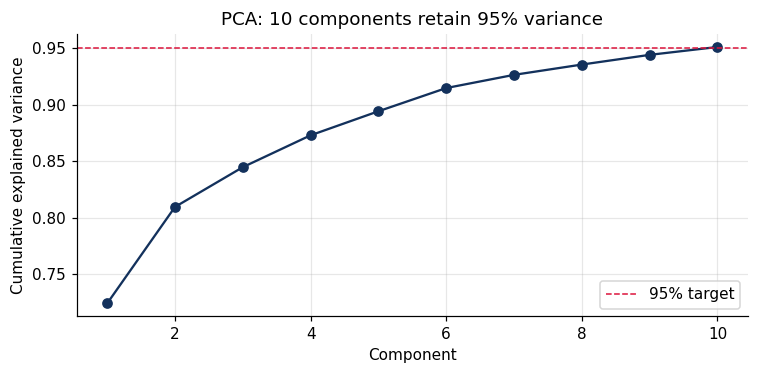

In [4]:
Xp, pca_model, n_comp = run_pca(pre.X, variance_target=0.95)
print(f'PCA -> {n_comp} components retained for 95% variance')

fig, ax = plt.subplots(figsize=(7, 3.5))
cum = np.cumsum(pca_model.explained_variance_ratio_)
ax.plot(range(1, len(cum)+1), cum, 'o-', color='#13315C')
ax.axhline(0.95, color='crimson', ls='--', lw=1, label='95% target')
ax.set_xlabel('Component'); ax.set_ylabel('Cumulative explained variance')
ax.set_title(f'PCA: {n_comp} components retain 95% variance')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR/'pca_variance.png'); plt.show()

### Top loadings on PC1 and PC2

These tell us what the **dominant axes of variation** are.

In [5]:
loadings = pd.DataFrame(pca_model.components_[:2].T,
                        index=pre.feature_names, columns=['PC1', 'PC2'])
print('Top |loadings| on PC1:')
print(loadings['PC1'].abs().sort_values(ascending=False).head(8).round(3))
print()
print('Top |loadings| on PC2:')
print(loadings['PC2'].abs().sort_values(ascending=False).head(8).round(3))

Top |loadings| on PC1:
half_life_hours            0.996
chart_presence_ratio       0.048
hours_to_first_trend       0.045
returned_count             0.040
days_observed_on_chart     0.031
comment_like_ratio         0.017
decay_log_slope_48h        0.010
mean_comment_view_ratio    0.010
Name: PC1, dtype: float64

Top |loadings| on PC2:
hours_to_first_trend         0.813
duration_seconds             0.453
mean_views_per_hour          0.152
peak_views_per_hour          0.149
decay_log_slope_48h          0.131
days_observed_on_chart       0.101
mean_comment_view_ratio      0.097
channel_size_bucket=large    0.091
Name: PC2, dtype: float64


## 4. K-Means scan: choose `k` carefully

We compute **silhouette**, **Calinski-Harabasz**, and **max-cluster-share** for k = 2..10.
Silhouette alone can be misleading: it tends to pick degenerate splits where one tiny dense cluster pulls away from a big blob. We disqualify any `k` where the largest cluster exceeds 55% of the data — those splits aren't useful for surfacing archetypes.

In [6]:
scan = kmeans_scan(Xp, k_range=range(2, 11))
scan.round(3)

,k,inertia,silhouette,calinski_harabasz,max_cluster_share
0,2,10002.531,0.621,276.939,0.797
1,3,6462.114,0.610,285.566,0.797
2,4,5057.447,0.590,266.585,0.797
3,5,3727.644,0.470,293.507,0.654
4,6,3245.782,0.329,276.351,0.459
5,7,2850.994,0.350,267.151,0.432
6,8,2515.220,0.362,263.473,0.432
7,9,2242.816,0.373,261.439,0.267
8,10,2013.654,0.387,261.067,0.259


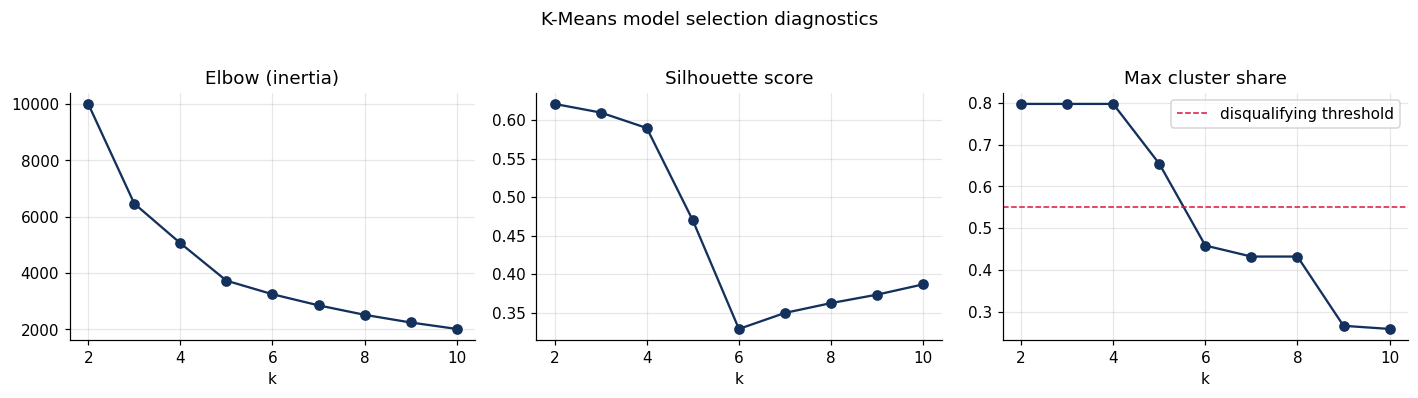

Chosen k = 10 (highest silhouette among non-degenerate splits)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(scan['k'], scan['inertia'], 'o-', color='#13315C')
axes[0].set_title('Elbow (inertia)'); axes[0].set_xlabel('k'); axes[0].grid(alpha=0.3)
axes[1].plot(scan['k'], scan['silhouette'], 'o-', color='#13315C')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k'); axes[1].grid(alpha=0.3)
axes[2].plot(scan['k'], scan['max_cluster_share'], 'o-', color='#13315C')
axes[2].axhline(0.55, color='crimson', ls='--', lw=1, label='disqualifying threshold')
axes[2].set_title('Max cluster share'); axes[2].set_xlabel('k')
axes[2].legend(); axes[2].grid(alpha=0.3)
fig.suptitle('K-Means model selection diagnostics', y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/'kmeans_scan.png', bbox_inches='tight'); plt.show()

k_best = suggest_k(scan, max_imbalance=0.55)
print(f'Chosen k = {k_best} (highest silhouette among non-degenerate splits)')

## 5. Fit the chosen models and compare them

In [8]:
_, km_labels = fit_kmeans(Xp, k=k_best)
ag_labels = fit_agglomerative(Xp, k=k_best)

kd = k_distance_curve(Xp, k=5)
eps = float(np.percentile(kd, 90))
db_labels = fit_dbscan(Xp, eps=eps, min_samples=5)

print(f'K-Means    silhouette = {silhouette_score(Xp, km_labels):.3f}, sizes = {sorted(pd.Series(km_labels).value_counts().tolist(), reverse=True)}')
print(f'Agglom     silhouette = {silhouette_score(Xp, ag_labels):.3f}, sizes = {sorted(pd.Series(ag_labels).value_counts().tolist(), reverse=True)}')
if len(set(db_labels)) > 1 and (db_labels != -1).sum() > 5:
    mask = db_labels != -1
    print(f'DBSCAN     silhouette = {silhouette_score(Xp[mask], db_labels[mask]):.3f}, '
          f'noise = {(db_labels == -1).sum()}, sizes = {sorted(pd.Series(db_labels[mask]).value_counts().tolist(), reverse=True)}')
else:
    print('DBSCAN: not enough structure (mostly noise) -- expected; lifecycle data is dense')

print(f'ARI(KMeans, Agglomerative) = {adjusted_rand_score(km_labels, ag_labels):.3f}')
print('  -> high ARI means the two methods agree on the partition; the structure is real, not algorithm-dependent.')

K-Means    silhouette = 0.387, sizes = [69, 52, 45, 44, 30, 9, 7, 7, 2, 1]
Agglom     silhouette = 0.389, sizes = [73, 54, 44, 38, 25, 14, 8, 7, 2, 1]
DBSCAN     silhouette = 0.484, noise = 13, sizes = [188, 41, 10, 7, 7]
ARI(KMeans, Agglomerative) = 0.916
  -> high ARI means the two methods agree on the partition; the structure is real, not algorithm-dependent.


**Validation against ground truth (synthetic data only).**

Because we're developing on synthetic data with known archetype labels, we can compute ARI vs ground truth — this proves the pipeline works. *Skip this cell when running on real data.*

In [9]:
if '_true_archetype' in features.columns:
    truth = features['_true_archetype']
    print(f'ARI(KMeans, ground truth) = {adjusted_rand_score(truth, km_labels):.3f}')
    print()
    print('Cross-tab (rows = ground-truth archetype, cols = predicted cluster):')
    print(pd.crosstab(truth, pd.Series(km_labels, index=features.index, name='cluster'),
                      margins=True))

ARI(KMeans, ground truth) = 0.600

Cross-tab (rows = ground-truth archetype, cols = predicted cluster):
cluster          0   1  2  3  4   5   6   7  8   9  All
_true_archetype                                        
drumbeat         0   3  1  2  1   0  30   2  0   2   41
firework         0  18  0  0  4   0   0   4  0  67   93
marathon         5   0  0  0  0   0   0   0  9   0   14
megaphone        0   9  0  0  1   0   0  39  0   0   49
snack            2  14  0  0  1  52   0   0  0   0   69
All              7  44  1  2  7  52  30  45  9  69  266


## 6. Profile clusters

In [10]:
features = features.assign(cluster=km_labels)
prof = profile_clusters(features.drop(columns=['cluster']), km_labels)

interesting = [
    'peak_views_per_hour', 'mean_views_per_hour', 'half_life_hours',
    'chart_presence_ratio', 'returned_count', 'days_observed_on_chart',
    'mean_like_view_ratio', 'mean_comment_view_ratio',
    'duration_seconds', 'tag_count', 'channel_subs',
]
interesting = [c for c in interesting if c in prof.columns]
prof[interesting].round(2)

,peak_views_per_hour,mean_views_per_hour,half_life_hours,chart_presence_ratio,returned_count,days_observed_on_chart,mean_like_view_ratio,mean_comment_view_ratio,duration_seconds,tag_count,channel_subs
cluster,,,,,,,,,,,
0,-0.20,-0.03,-0.51,0.22,-0.22,-1.18,-0.30,-0.77,1.71,0.14,-0.44
1,0.34,0.22,0.86,0.05,-0.04,0.46,-0.02,-0.11,-0.31,0.01,0.15
2,-0.99,-0.81,7.72,-6.17,3.61,1.09,-0.59,1.45,2.14,0.09,-0.76
3,-1.11,-1.01,3.60,-4.76,5.52,1.09,-0.18,1.91,1.16,-0.56,-0.35
4,-0.02,0.17,2.23,0.22,-0.22,0.33,-0.04,-0.26,-0.11,-0.25,0.54
5,0.34,0.49,-0.51,0.22,-0.22,-0.41,1.45,-0.61,-0.74,-1.10,0.20
6,-1.05,-1.02,-0.51,-0.54,0.55,-0.06,-0.03,1.32,1.36,-0.01,-0.63
7,0.32,0.25,-0.51,-0.03,0.04,0.59,-0.98,-0.88,-0.30,1.40,-1.03
8,-1.44,-1.27,NaN,0.22,-0.22,-1.41,-0.08,-0.56,2.74,0.24,-0.77


### Hero visual #1 — Cluster fingerprint heatmap

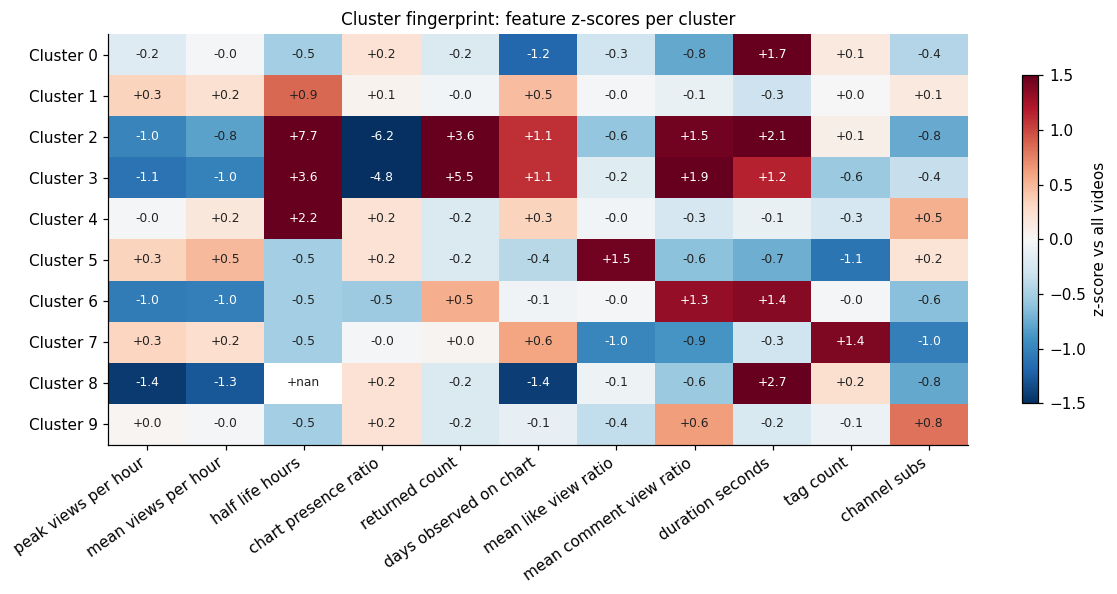

In [11]:
fig, ax = plt.subplots(figsize=(11, max(3, 0.45*k_best + 1)))
data = prof[interesting].values
im = ax.imshow(data, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')
ax.set_xticks(range(len(interesting)))
ax.set_xticklabels([c.replace('_', ' ') for c in interesting], rotation=35, ha='right')
ax.set_yticks(range(k_best))
ax.set_yticklabels([f'Cluster {i}' for i in range(k_best)])
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        ax.text(j, i, f'{v:+.1f}', ha='center', va='center',
                color='white' if abs(v) > 0.9 else '#222', fontsize=8)
fig.colorbar(im, ax=ax, label='z-score vs all videos', shrink=0.8)
ax.set_title('Cluster fingerprint: feature z-scores per cluster', fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR/'cluster_fingerprint.png', bbox_inches='tight'); plt.show()

### Naming the archetypes

Read each row of the fingerprint and pick a name:
- High peak velocity + low half-life + low like/view -> **Firework**
- Low velocity + long half-life + high like/view + long duration -> **Marathon**
- Returned-count > 0 + medium velocity -> **Drumbeat**
- High velocity + LOW like/view + high tag count -> **Megaphone**
- Very short duration + high like/view + fast cycle -> **Snack**

Edit the `cluster_names` dict below after inspecting the fingerprint output.

In [12]:
# TODO: Edit this after inspecting the fingerprint heatmap above
cluster_names = {i: f'Cluster {i}' for i in range(k_best)}
# Example: cluster_names = {0: 'Firework', 1: 'Marathon', 2: 'Drumbeat', 3: 'Megaphone', 4: 'Snack'}

features['archetype'] = features['cluster'].map(cluster_names)
features.groupby('archetype').size().to_frame('n')

,n
archetype,
Cluster 0,7
Cluster 1,44
Cluster 2,1
Cluster 3,2
Cluster 4,7
Cluster 5,52
Cluster 6,30
Cluster 7,45
Cluster 8,9


### Top representative videos per cluster

For each cluster, find the videos closest to the centroid — these are the 'poster children' for the archetype.

In [13]:
first_snap = (snapshots.sort_values('snapshot_ts')
                        .groupby('video_id').first())

centroids = np.array([Xp[km_labels == c].mean(axis=0) for c in range(k_best)])
for c in range(k_best):
    mask = km_labels == c
    pts = Xp[mask]
    ids = features.index[mask]
    d = euclidean_distances(pts, centroids[c:c+1]).ravel()
    nearest = ids[np.argsort(d)[:3]]
    print(f'Cluster {c} ({cluster_names.get(c, "?")}, n={mask.sum()}):')
    for vid in nearest:
        if vid in first_snap.index:
            row = first_snap.loc[vid]
            title_str = str(row['title'])
            title = (title_str[:80] + '...') if len(title_str) > 80 else title_str
            print(f'  - {title}  [{row["channel_title"]}]')
    print()

Cluster 0 (Cluster 0, n=7):
  - How to Deep Dive  [Channel_marathon_3561]
  - Top 10 Education you must watch  [Channel_marathon_6465]
  - How to Documentary  [Channel_marathon_2214]

Cluster 1 (Cluster 1, n=44):
  - Breaking reaction  [Channel_firework_2341]
  - Live - explained in 10 minutes  [Channel_firework_7210]
  - First Look reaction  [Channel_firework_2360]

Cluster 2 (Cluster 2, n=1):
  - Talkshow song official video  [Channel_drumbeat_6624]

Cluster 3 (Cluster 3, n=2):
  - Vlog reaction  [Channel_drumbeat_8079]
  - Comedy - explained in 10 minutes  [Channel_drumbeat_8585]

Cluster 4 (Cluster 4, n=7):
  - How to Release  [Channel_firework_6960]
  - Trending short #shorts  [Channel_firework_9496]
  - Top 10 Trending you must watch  [Channel_firework_7862]

Cluster 5 (Cluster 5, n=52):
  - Shorts | Episode 40  [Channel_snack_8987]
  - Shorts review 2026  [Channel_snack_2193]
  - Asmr reaction  [Channel_snack_4613]

Cluster 6 (Cluster 6, n=30):
  - Talkshow | Episode 34  [Channe

## 7. Hero visual #2 — Per-cluster lifecycle curves

For each cluster, plot the average view-count trajectory over time. This is the visual that makes the archetypes *click* — Marathon plateaus, Firework spikes-and-dies, Drumbeat re-enters, etc.

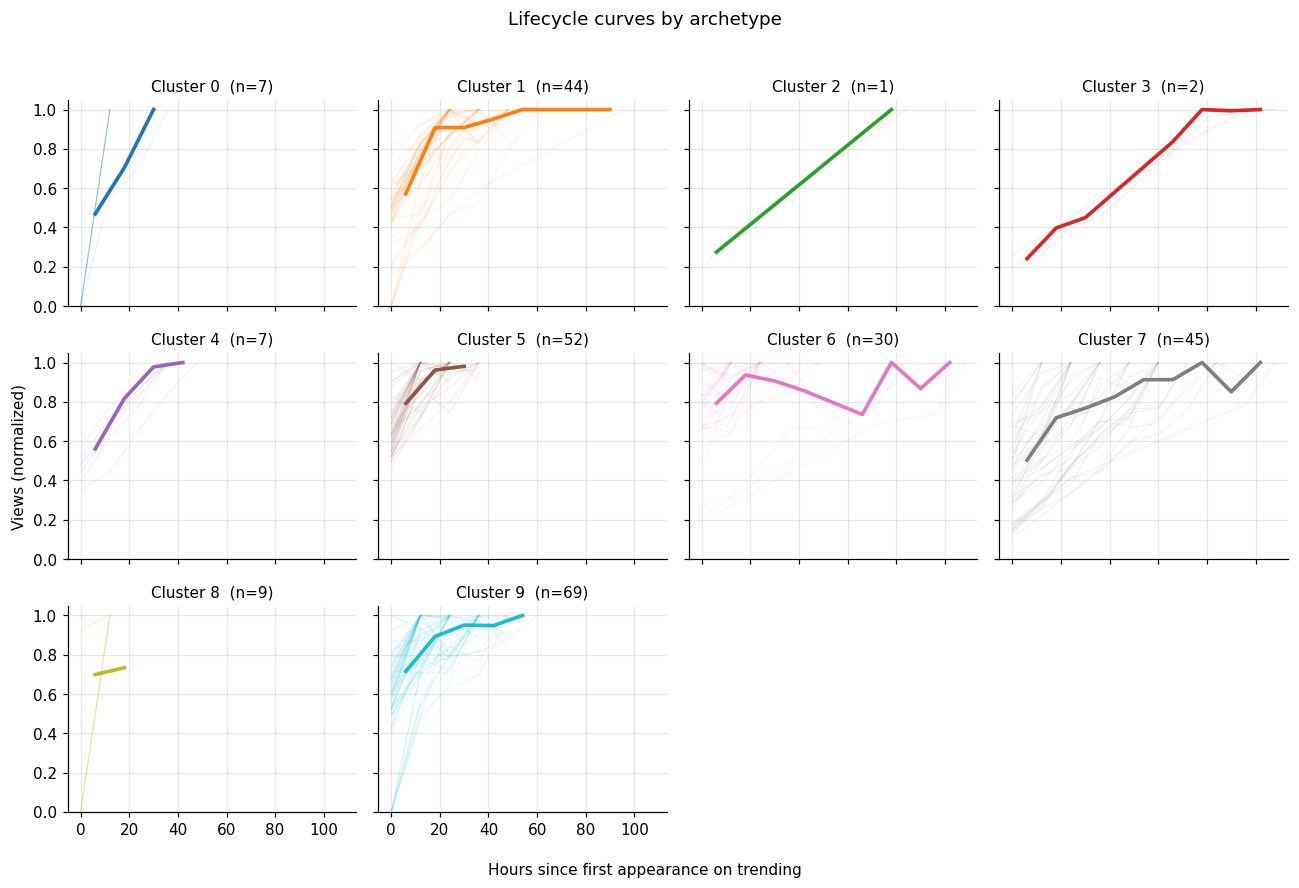

In [14]:
colors = plt.cm.tab10.colors

snap = snapshots.copy()
snap['snapshot_ts'] = pd.to_datetime(snap['snapshot_ts'], utc=True).dt.tz_convert(None)
snap = snap.merge(features[['cluster']], left_on='video_id', right_index=True)

snap = snap.sort_values(['video_id', 'snapshot_ts'])
snap['t0'] = snap.groupby('video_id')['snapshot_ts'].transform('min')
snap['hours_in'] = (snap['snapshot_ts'] - snap['t0']).dt.total_seconds() / 3600
snap['view_norm'] = snap.groupby('video_id')['view_count'].transform(
    lambda v: v / v.max() if v.max() > 0 else v
)

ncols = min(k_best, 4); nrows = int(np.ceil(k_best / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 2.6*nrows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for c in range(k_best):
    ax = axes[c]
    sub = snap[snap['cluster'] == c]
    for vid, grp in sub.groupby('video_id'):
        ax.plot(grp['hours_in'], grp['view_norm'],
                color=colors[c % 10], alpha=0.10, lw=0.7)
    if not sub.empty and sub['hours_in'].max() > 0:
        bins = np.arange(0, sub['hours_in'].max() + 12, 12)
        if len(bins) > 1:
            sub2 = sub.assign(bin=pd.cut(sub['hours_in'], bins, include_lowest=True))
            means = sub2.groupby('bin', observed=True)['view_norm'].mean()
            centers = [iv.mid for iv in means.index]
            ax.plot(centers, means.values, color=colors[c % 10], lw=2.4)
    ax.set_title(f'{cluster_names.get(c, f"Cluster {c}")}  (n={(km_labels==c).sum()})',
                 fontsize=10)
    ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
for ax in axes[k_best:]:
    ax.set_visible(False)
fig.supxlabel('Hours since first appearance on trending', fontsize=10)
fig.supylabel('Views (normalized)', fontsize=10)
fig.suptitle('Lifecycle curves by archetype', fontsize=12, y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/'lifecycle_curves.png', bbox_inches='tight'); plt.show()

## 8. Hero visual #3 — 2D embedding map

UMAP projection of all videos, coloured by archetype. *This is the title-page visual of the deck.*

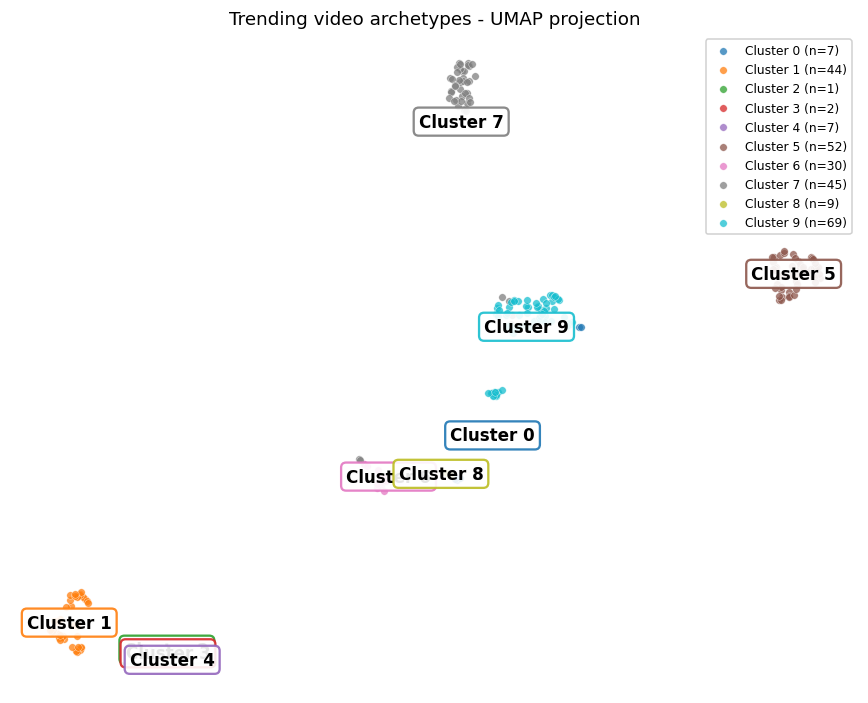

In [15]:
emb = umap_embed(Xp, n_neighbors=15)

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in range(k_best):
    mask = km_labels == c
    ax.scatter(emb[mask, 0], emb[mask, 1],
               s=24, alpha=0.75, color=colors[c % 10],
               edgecolor='white', lw=0.3,
               label=f'{cluster_names.get(c, f"Cluster {c}")} (n={mask.sum()})')
    cx, cy = emb[mask, 0].mean(), emb[mask, 1].mean()
    ax.annotate(cluster_names.get(c, f'C{c}'), (cx, cy),
                fontsize=11, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec=colors[c % 10], lw=1.5, alpha=0.9))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Trending video archetypes - UMAP projection', fontsize=12)
ax.legend(loc='best', fontsize=8, framealpha=0.9)
for spine in ax.spines.values(): spine.set_visible(False)
fig.tight_layout(); fig.savefig(FIG_DIR/'umap_map.png', bbox_inches='tight'); plt.show()

## 9. Association mining on tag baskets

Apriori on the tags of each video. We filter to the top-80 most-common tags first to keep the search tractable, and require lift >= 1.5 for an interesting rule.

In [16]:
baskets = build_tag_baskets(snapshots, features.index)
rules = mine_rules(baskets, min_support=0.05, min_confidence=0.4, min_lift=1.5)
print(f'Rules found: {len(rules)}')
if not rules.empty:
    show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    print('Top 15 by lift:')
    print(rules[show].head(15).to_string(index=False))

Rules found: 15448
Top 15 by lift:
                       antecedents                        consequents  support  confidence  lift
frozenset({documentary, longform})              frozenset({tutorial}) 0.052632         1.0  19.0
frozenset({tutorial, documentary})               frozenset({concept}) 0.052632         1.0  19.0
                 frozenset({neet})  frozenset({documentary, concept}) 0.052632         1.0  19.0
              frozenset({concept})     frozenset({documentary, neet}) 0.052632         1.0  19.0
          frozenset({documentary})         frozenset({concept, neet}) 0.052632         1.0  19.0
        frozenset({concept, neet})           frozenset({documentary}) 0.052632         1.0  19.0
    frozenset({documentary, neet})               frozenset({concept}) 0.052632         1.0  19.0
 frozenset({documentary, concept})                  frozenset({neet}) 0.052632         1.0  19.0
             frozenset({longform})  frozenset({documentary, concept}) 0.052632         1.0  

### Per-cluster distinctive tags (lift)

Which tags are characteristic of each cluster, vs being generic across all videos?

In [17]:
from collections import Counter
video_tags = (snapshots.sort_values('snapshot_ts')
                       .groupby('video_id')['tags'].first()
                       .fillna('')
                       .map(lambda s: set(t for t in s.split('|') if t)))
video_tags = video_tags.loc[features.index]

all_tag_count = Counter(t for tags in video_tags for t in tags)
n_total = len(video_tags)
p_overall = {t: c/n_total for t, c in all_tag_count.items()}

for c in range(k_best):
    in_cluster = video_tags[features['cluster'] == c]
    n_c = len(in_cluster)
    if n_c == 0: continue
    cluster_tag_count = Counter(t for tags in in_cluster for t in tags)
    rows = []
    for t, k in cluster_tag_count.items():
        if k < 3: continue
        p_in = k / n_c
        lift = p_in / p_overall[t]
        if lift > 1.5:
            rows.append((t, k, p_in, lift))
    rows.sort(key=lambda r: -r[3])
    name = cluster_names.get(c, f'Cluster {c}')
    print(f'{name} (n={n_c}) - distinctive tags (lift > 1.5):')
    for t, k, p, lift in rows[:8]:
        print(f'  {t:<25s}  in {k}/{n_c} videos  ({p:.1%}, lift={lift:.2f})')
    print()

Cluster 0 (n=7) - distinctive tags (lift > 1.5):
  study                      in 5/7 videos  (71.4%, lift=17.27)
  lecture                    in 5/7 videos  (71.4%, lift=15.83)
  deep dive                  in 5/7 videos  (71.4%, lift=15.83)
  biology                    in 5/7 videos  (71.4%, lift=14.62)
  explained                  in 5/7 videos  (71.4%, lift=14.62)
  iitjee                     in 5/7 videos  (71.4%, lift=14.62)
  longform                   in 5/7 videos  (71.4%, lift=13.57)
  analysis                   in 5/7 videos  (71.4%, lift=13.57)

Cluster 1 (n=44) - distinctive tags (lift > 1.5):
  asmr                       in 10/44 videos  (22.7%, lift=1.95)
  funny                      in 9/44 videos  (20.5%, lift=1.51)

Cluster 2 (n=1) - distinctive tags (lift > 1.5):

Cluster 3 (n=2) - distinctive tags (lift > 1.5):

Cluster 4 (n=7) - distinctive tags (lift > 1.5):
  breaking                   in 4/7 videos  (57.1%, lift=1.95)
  exclusive                  in 4/7 videos  (5

## 10. Save outputs for the deck

In [18]:
out = features.copy()
out.to_csv('../data/videos_with_clusters.csv')
if not rules.empty:
    rules.head(50).to_csv('../data/top_association_rules.csv', index=False)
print('Saved: videos_with_clusters.csv, top_association_rules.csv')
print(f'Figures saved to: {FIG_DIR}')

Saved: videos_with_clusters.csv, top_association_rules.csv
Figures saved to: ../docs/figures
